<a href="https://colab.research.google.com/github/Ayu-sshhhhh/SkimLit/blob/main/SkimLit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import datetime
print(f"Last run on {datetime.datetime.now()}")

Last run on 2026-08-01 05:56:11.428463


# Get data

In [2]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 20.21 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [3]:
!ls pubmed-rct/

PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


`PubMed_200k_RCT` is the same as `PubMed_200k_RCT_numbers_replaced_with_at_sign`, except that in the latter all numbers had been replaced by @. (same for `PubMed_20k_RCT` vs. `PubMed_20k_RCT_numbers_replaced_with_at_sign`).

`PubMed_20k_RCT` is a subset of `PubMed_200k_RCT`

The dataset we are going to be focused on is `PubMed_20k_RCT_numbers_replaced_with_at_sign`

In [4]:
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/

dev.txt  test.txt  train.txt


- train.txt - training samples.
- dev.txt - dev is short for development set, which is another name for validation set.
- test.txt - test samples.

In [5]:
data_dir = "pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [6]:
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt']

In [7]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2026-08-01 05:56:23--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0.001s  

2026-08-01 05:56:23 (18.5 MB/s) - ‘helper_functions.py’ saved [10246/10246]



# Preprocessing

In [8]:
# Creating a func. to read lines of a doc
def get_lines(filename):
  """
  Reads filename (a text file) and return the lines of text as a list.

  Args:
    filename : a string containing the target filepath to read.

  Returns:
    A list of strings with one string per line from the target filename.
    For ex:
    ["this is the 1st line of filename",
    "this is the second line of filename",
    ...]
"""
  with open(filename, "r") as f:
    return f.readlines()

In [9]:
train_lines = get_lines(data_dir + "train.txt")
train_lines[:10]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [10]:
def preprocess_text_with_line_numbers(filename):
  """
  Returns a list of dict of abstract line data.

  Takes in filename, reads its contents and sorts throug each line, extracting things like the target label, the text of the sentence, how many sentneces are in the current abstract and what sentence number the target line is.

  Args:
    filename : a string of the target text file to read and extract lines from.

  Returns:
    A list of dicts each containing a line from an abstract, the lines label, the lines position in the abstract and the total number of lines in the abstract where the line is from.For example:

      [{"target": 'CONCLUSION',
        "text": The study couldn't have gone better, turns out people are kinder than you think",
        "line_number": 8,
        "total_lines": 8}]
  """
  input_lines = get_lines(filename)
  abstract_lines = ""
  abstract_samples = []

  for line in input_lines:
    if line.startswith("###"):
      abstract_id = line
      abstract_lines = ""
    elif line.isspace():
      abstract_line_split = abstract_lines.splitlines()

      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {}
        target_text_split = abstract_line.split("\t")
        line_data["target"] = target_text_split[0]
        line_data["text"] = target_text_split[1].lower()
        line_data["line_number"] = abstract_line_number
        line_data["total_lines"] = len(abstract_line_split) -1
        abstract_samples.append(line_data)
    else:
      abstract_lines += line
  return abstract_samples

In [11]:
%%time
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir +"dev.txt")
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")
len(train_samples), len(val_samples), len(test_samples)

CPU times: user 353 ms, sys: 74.9 ms, total: 428 ms
Wall time: 428 ms


(180040, 30212, 30135)

In [12]:
train_samples[:10]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [13]:
import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head()

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


In [14]:
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


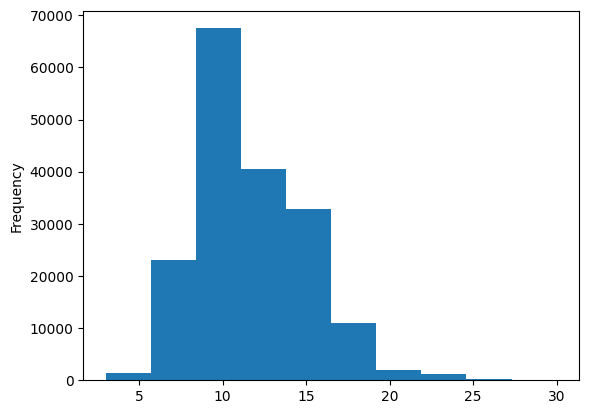

In [15]:
train_df.total_lines.plot.hist();

In [16]:
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

## Make numeric labels

In [17]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1,1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1,1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1,1))

In [18]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [19]:
class_names = label_encoder.classes_
class_names

array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
      dtype=object)

# Model Experiments

## Model 0 (baseline model)

Our baseline model will be a TF-IDF Multinomial Naive Bayes as recommended by `Scikit-Learn's machine learning map`

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model_0 = Pipeline([
    ("tf-idf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

model_0.fit(train_sentences, train_labels_encoded)

Pipeline(steps=[('tf-idf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [22]:
model_0.score(val_sentences, val_labels_encoded)

0.7218323844829869

In [23]:
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

In [24]:
from helper_functions import calculate_results

baseline_results = calculate_results(val_labels_encoded, baseline_preds)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

# Data Prep for deep sequence models

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [26]:
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len

np.float64(26.338269273494777)

In [27]:
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

55

In our training set, 95% of the sentences have length of 55 tokens or less.

## Text Vectorization

In [28]:
max_tokens = 68000
from tensorflow.keras.layers import TextVectorization
text_vectorizer = TextVectorization(max_tokens=max_tokens,
                                    output_sequence_length = 55)

In [29]:
text_vectorizer.adapt(train_sentences)

In [30]:
# Testing out vectorizerr
import random
target_sent = random.choice(train_sentences)
print(f"Text: \n{target_sent}")
print(f"Length of text : {len(target_sent.split())}")

Text: 
treatment consisted of @-week supplementation with @ g/d pectin ( fiber group ) or maltodextrin ( placebo group ) .
Length of text : 20


In [31]:
rct_20K_text_vocab = text_vectorizer.get_vocabulary()
rct_20K_text_vocab[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('and'),
 np.str_('of'),
 np.str_('in'),
 np.str_('to'),
 np.str_('with'),
 np.str_('a'),
 np.str_('were')]

In [32]:
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

## Embedding

In [33]:
token_embed = layers.Embedding(input_dim=len(rct_20K_text_vocab),
                               output_dim = 128,
                               mask_zero=False,
                               name='token_embedding')
vectorized_sentence = text_vectorizer([target_sent])
embedded_sentence = token_embed(vectorized_sentence)
print(vectorized_sentence.shape)
print(embedded_sentence.shape)

(1, 55)
(1, 55, 128)


In [34]:
print(len(train_sentences), train_labels_one_hot.shape)
print(len(val_sentences), val_labels_one_hot.shape)
print(len(test_sentences), test_labels_one_hot.shape)

180040 (180040, 5)
30212 (30212, 5)
30135 (30135, 5)


In [35]:
train_labels_one_hot = train_labels_one_hot.toarray()
val_labels_one_hot = val_labels_one_hot.toarray()
test_labels_one_hot = test_labels_one_hot.toarray()

In [36]:
train_dataset = tf.data.Dataset.from_tensor_slices((tf.constant(train_sentences, dtype=tf.string), train_labels_one_hot))
val_dataset = tf.data.Dataset.from_tensor_slices((tf.constant(val_sentences, dtype=tf.string), val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((tf.constant(test_sentences, dtype=tf.string), test_labels_one_hot))

In [37]:
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [38]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_

All of our deep models will follow a similar structure:

    Input (text) -> Tokenize -> Embedding -> Layers -> Output (label probability)

The main component we'll be changing throughout is the `Layers` component.

## Model 1 : Conv1D

In [39]:
inputs = layers.Input(shape=(), dtype=tf.string)
text_vectors = text_vectorizer(inputs)
token_embeddings = token_embed(text_vectors)
x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(token_embeddings)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_1 = tf.keras.Model(inputs, outputs)

model_1.compile(loss='categorical_crossentropy',
                optimizer="Adam",
                metrics=["accuracy"])

In [40]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model_1_history = model_1.fit(train_dataset,
                              steps_per_epoch = int(0.1* len(train_dataset)),
                              epochs=3,
                              validation_data = val_dataset,
                              validation_steps = int(0.1* len(val_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6341 - loss: 0.9282 - val_accuracy: 0.7374 - val_loss: 0.7013
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7508 - loss: 0.6723 - val_accuracy: 0.7640 - val_loss: 0.6488
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7694 - loss: 0.6304 - val_accuracy: 0.7816 - val_loss: 0.6098


In [43]:
model_1.evaluate(val_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7805 - loss: 0.6116


[0.6115548610687256, 0.7804845571517944]

In [45]:
model_1_pred_probs = model_1.predict(val_dataset)
model_1_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


array([[3.9576992e-01, 2.2600825e-01, 1.0048454e-01, 2.4413930e-01,
        3.3598021e-02],
       [4.3733928e-01, 2.8332517e-01, 6.7835399e-03, 2.6736918e-01,
        5.1828274e-03],
       [1.5884258e-01, 1.5095507e-02, 2.6009805e-03, 8.2341290e-01,
        4.8043632e-05],
       ...,
       [3.4197562e-06, 1.0302695e-03, 6.8608357e-04, 1.0445464e-06,
        9.9827921e-01],
       [5.6998618e-02, 4.2808640e-01, 1.1111992e-01, 4.7522679e-02,
        3.5627243e-01],
       [2.1552742e-01, 5.8081400e-01, 5.0061155e-02, 4.9433801e-02,
        1.0416360e-01]], dtype=float32)

In [46]:
model_1_preds = tf.argmax(model_1_pred_probs, axis=1)

In [47]:
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>

In [48]:
model_1_results = calculate_results(val_labels_encoded, model_1_preds)
model_1_results

{'accuracy': 78.04845756652986,
 'precision': 0.7772968417526511,
 'recall': 0.7804845756652986,
 'f1': 0.7783448831248166}